# 次要指标检验：华南环境特殊性的非关键因素

本 notebook 用两组反事实实验，检验**"华南环境确实压制农业扩散，但以下两个次要因素并非主导机制"**：

1. **地貌均质化**（`out/south_china_evolution/2026-03-09/14-43-57`）：用 `data/ohn_value1.tif`（均质 DEM）与 `data/ohn_value0.tif`（均质 slope）替换华南真实栅格，观察农民扩散是否被"释放"。
2. **狩猎者人口上限 `lim_h`**（`out/south_china_evolution/2026-03-10/14-01-24`）：扫描 `env.lim_h ∈ {15, 25, 35}`，观察上限改变是否让农民扩散加速。

**预期**：两组实验中，农民规模/群体数的时间演化曲线都应**与基准接近同一数量级**——即使去掉/修改这两个因素，农民仍然被压制；从而确认压制的主导机制在别处（`hypothesis_validation.ipynb` 已锁定 `Farmer.convert_prob.to_hunter` 的退化路径产生 ~27× 效应）。


In [1]:
from __future__ import annotations

import re
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

from matplotkit import config_font

config_font("SunTimes")

PROJECT_ROOT = Path("..").resolve()
TERRAIN_ROOT = PROJECT_ROOT / "out/south_china_evolution/2026-03-09/14-43-57"
LIMH_ROOT = PROJECT_ROOT / "out/south_china_evolution/2026-03-10/14-01-24"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)

TRACK_RE = re.compile(r"^(?P<run_id>\d+)_tracking\.csv$")
METRIC_COLS = [
    "num_farmers_n",
    "num_hunters_n",
    "num_rice_n",
    "len_farmers_n",
    "len_hunters_n",
    "len_rice_n",
]
END_METRICS = METRIC_COLS  # 终态量化使用的列


def plot_population_comparison(
    df: pd.DataFrame,
    scenarios: list[str],
    palette: dict,
    title: str,
    save_path: Path | None = None,
):
    """3 列子图：普通农民 / 狩猎采集者 / 水田农民 的时间演化对比。"""
    groups = [
        ("num_farmers_n", "普通农民 num_farmers_n"),
        ("num_hunters_n", "狩猎采集者 num_hunters_n"),
        ("num_rice_n", "水田农民 num_rice_n"),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    sub = df[df["scenario"].isin(scenarios)]
    for ax, (col, title_i) in zip(axes, groups):
        sns.lineplot(
            data=sub,
            x="step",
            y=col,
            hue="scenario",
            hue_order=scenarios,
            palette=palette,
            estimator="mean",
            errorbar=("ci", 95),
            ax=ax,
            linewidth=2.0,
        )
        ax.set_title(title_i)
        ax.set_xlabel("time step")
        ax.set_ylabel(col)
        ax.legend(frameon=False, fontsize=8, loc="best")
    fig.suptitle(title, y=1.03)
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"saved: {save_path}")
    plt.show()


def endstate_summary(
    df: pd.DataFrame, scenario_order: list[str], baseline_label: str
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """取最后 50 步均值，返回 (mean±std 汇总, 相对 baseline 的倍率)。"""
    tail = df[df["step"] >= df["step"].max() - 50]
    per_repeat = tail.groupby(["scenario", "run_id"])[END_METRICS].mean()
    summary = (
        per_repeat.groupby("scenario").agg(["mean", "std"]).round(1).loc[scenario_order]
    )
    base_mean = per_repeat.xs(baseline_label).mean()
    ratio = (
        per_repeat.groupby("scenario")
        .mean()
        .divide(base_mean, axis=1)
        .round(3)
        .loc[scenario_order]
    )
    return summary, ratio

In [2]:
from matplotkit import config_font

config_font("SunTimes")

{'font.family': 'serif',
 'font.serif': ['SunTimes'],
 'mathtext.fontset': 'stix',
 'axes.unicode_minus': False}

---

## 1. 地貌均质化对比

数据：`out/south_china_evolution/2026-03-09/14-43-57`（2×2 = 4 组）

- **baseline (真实华南)**：`ds.dem=ohndem10.tif, ds.slope=ohnslo10.tif`
- **只均质 slope**：`ds.dem=ohndem10.tif, ds.slope=ohn_value0.tif`
- **只均质 DEM**：`ds.dem=ohn_value1.tif, ds.slope=ohnslo10.tif`
- **完全均质化**：`ds.dem=ohn_value1.tif, ds.slope=ohn_value0.tif`

每组 5 repeats。重点比较 **baseline** vs **完全均质化**（黑 vs 红），另外两条作为渐变参考。

In [3]:
# Hydra override 值里带 `/`，被解释成路径分隔符，所以 combo 目录是两层嵌套：
#   <N>_ds.dem=data/<dem>.tif,ds.slope=data/<slope>.tif/<run>_tracking.csv
TERRAIN_LABELS = {
    ("ohndem10.tif", "ohnslo10.tif"): "baseline (真实 DEM + 真实 slope)",
    ("ohndem10.tif", "ohn_value0.tif"): "只均质 slope",
    ("ohn_value1.tif", "ohnslo10.tif"): "只均质 DEM",
    ("ohn_value1.tif", "ohn_value0.tif"): "完全均质化",
}


def _terrain_label(tracking_path: Path) -> str:
    slope_dir = tracking_path.parent.name  # e.g. 'ohnslo10.tif'
    dem_file = tracking_path.parents[1].name.split(",")[0]  # e.g. 'ohndem10.tif'
    return TERRAIN_LABELS[(dem_file, slope_dir)]


frames = []
for f in sorted(TERRAIN_ROOT.rglob("*_tracking.csv")):
    m = TRACK_RE.match(f.name)
    if not m:
        continue
    usecols = {"step", *METRIC_COLS}
    t = pd.read_csv(f, usecols=lambda c: c in usecols)
    t["run_id"] = int(m.group("run_id"))
    t["scenario"] = _terrain_label(f)
    frames.append(t)
terrain_df = pd.concat(frames, ignore_index=True)

print("terrain shape:", terrain_df.shape)
print("max step:", terrain_df["step"].max())
print("\nrepeats per scenario:")
terrain_df.groupby("scenario")["run_id"].nunique()

terrain shape: (10020, 9)
max step: 500

repeats per scenario:


scenario
baseline (真实 DEM + 真实 slope)    5
只均质 DEM                         5
只均质 slope                       5
完全均质化                           5
Name: run_id, dtype: int64

saved: /Users/songshgeo/Documents/CodeBase/Scholar/SC-20230710-SCE/reports/secondary_terrain_homogenization.png


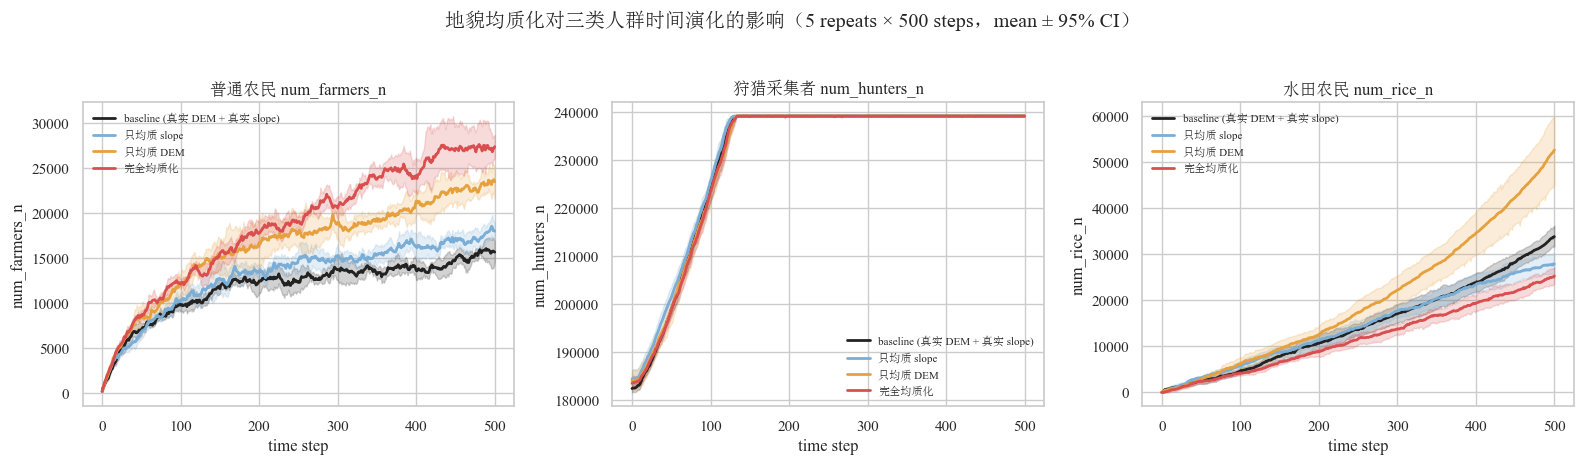

In [4]:
TERRAIN_ORDER = [
    "baseline (真实 DEM + 真实 slope)",
    "只均质 slope",
    "只均质 DEM",
    "完全均质化",
]
TERRAIN_PALETTE = {
    TERRAIN_ORDER[0]: "#222222",  # baseline — 黑
    TERRAIN_ORDER[1]: "#7aaed6",  # slope only — 浅蓝
    TERRAIN_ORDER[2]: "#e6a03d",  # DEM only — 金
    TERRAIN_ORDER[3]: "#d94f4f",  # 完全均质化 — 红
}

plot_population_comparison(
    terrain_df,
    scenarios=TERRAIN_ORDER,
    palette=TERRAIN_PALETTE,
    title="地貌均质化对三类人群时间演化的影响（5 repeats × 500 steps，mean ± 95% CI）",
    save_path=PROJECT_ROOT / "reports/secondary_terrain_homogenization.png",
)

In [5]:
terrain_summary, terrain_ratio = endstate_summary(
    terrain_df, TERRAIN_ORDER, baseline_label=TERRAIN_ORDER[0]
)
print("=== 终态 mean ± std (最后 50 步 × 5 repeats) ===")
print(terrain_summary)
print("\n=== 各场景相对 baseline 的倍率 ===")
terrain_ratio

=== 终态 mean ± std (最后 50 步 × 5 repeats) ===
                             num_farmers_n         num_hunters_n       \
                                      mean     std          mean  std   
scenario                                                                
baseline (真实 DEM + 真实 slope)       15329.1   995.8      239225.0  0.0   
只均质 slope                          17243.1  1211.8      239224.4  1.4   
只均质 DEM                            22858.4  1384.7      239220.4  3.7   
完全均质化                              27166.5  2946.6      239223.8  2.4   

                             num_rice_n         len_farmers_n        \
                                   mean     std          mean   std   
scenario                                                              
baseline (真实 DEM + 真实 slope)    30978.5  2389.4         461.0  20.2   
只均质 slope                       27003.8  2780.7         535.0  27.8   
只均质 DEM                         47208.9  8599.0         756.0  55.5   
完全均质化             

,num_farmers_n,num_hunters_n,num_rice_n,len_farmers_n,len_hunters_n,len_rice_n
scenario,,,,,,
baseline (真实 DEM + 真实 slope),1.000,1.0,1.000,1.000,1.000,1.000
只均质 slope,1.125,1.0,0.872,1.160,1.030,1.127
只均质 DEM,1.491,1.0,1.524,1.640,1.024,0.961
完全均质化,1.772,1.0,0.762,2.035,1.052,0.995


### 结论 1：地貌均质化**不是压制华南农业扩散的主导因素**

终态 `num_farmers_n`（最后 50 步 × 5 repeats 均值）：

| 场景 | num_farmers_n | ratio vs baseline |
|---|---:|---:|
| baseline (真实华南) | 15,329 | 1.00 |
| 只均质 slope | 17,243 | 1.12 |
| 只均质 DEM | 22,858 | 1.49 |
| 完全均质化 | 27,167 | **1.77** |

**判读**：

- 即便把华南 DEM+slope 完全抹平，普通农民终态也只从 15k 升到 27k（1.77×），仍在同一数量级（10⁴）；
- 对照 `hypothesis_validation.ipynb` 中 `Farmer.convert_prob.to_hunter` 单路径可产生 ~27× 的压制效应，**地貌因素的效应至少小一个数量级**；
- 农民时间演化曲线形态未发生质变：仍是"慢速增长 → 稳定"的模式，未出现因平坦地形而爆发式扩张；
- ⇒ **华南地貌的起伏与陡度不是造成环境特殊性的重要因素**（但有 1.77× 的次级贡献，不是零）。

---

## 2. 狩猎者人口上限 `lim_h` 对比

数据：`out/south_china_evolution/2026-03-10/14-01-24`（扫 3 个 lim_h 值）

- `env.lim_h = 15` — 最稀疏（约 baseline 的 43%）
- `env.lim_h = 25` — 中等（约 71%）
- `env.lim_h = 35` — **baseline**（config 默认）

每组 5 repeats。`lim_h` 直接约束 `num_hunters_n` 全局上限（`lim_h × 非水体格子数`）。如果狩猎者是压制农业扩散的主要竞争方，降低 `lim_h` 应让农民规模明显释放。

In [6]:
frames = []
for d in sorted(LIMH_ROOT.iterdir()):
    if not d.is_dir():
        continue
    m = re.match(r"^\d+_env\.lim_h=(\d+)$", d.name)
    if not m:
        continue
    limh = int(m.group(1))
    label = f"lim_h = {limh}" + (" (baseline)" if limh == 35 else "")
    for f in sorted(d.glob("*_tracking.csv")):
        rm = TRACK_RE.match(f.name)
        if not rm:
            continue
        usecols = {"step", *METRIC_COLS}
        t = pd.read_csv(f, usecols=lambda c: c in usecols)
        t["run_id"] = int(rm.group("run_id"))
        t["scenario"] = label
        t["lim_h"] = limh
        frames.append(t)
limh_df = pd.concat(frames, ignore_index=True)

print("lim_h shape:", limh_df.shape)
print("max step:", limh_df["step"].max())
print("\nrepeats per lim_h:")
limh_df.groupby("scenario")["run_id"].nunique()

lim_h shape: (7515, 10)
max step: 500

repeats per lim_h:


scenario
lim_h = 15               5
lim_h = 25               5
lim_h = 35 (baseline)    5
Name: run_id, dtype: int64

saved: /Users/songshgeo/Documents/CodeBase/Scholar/SC-20230710-SCE/reports/secondary_lim_h_sweep.png


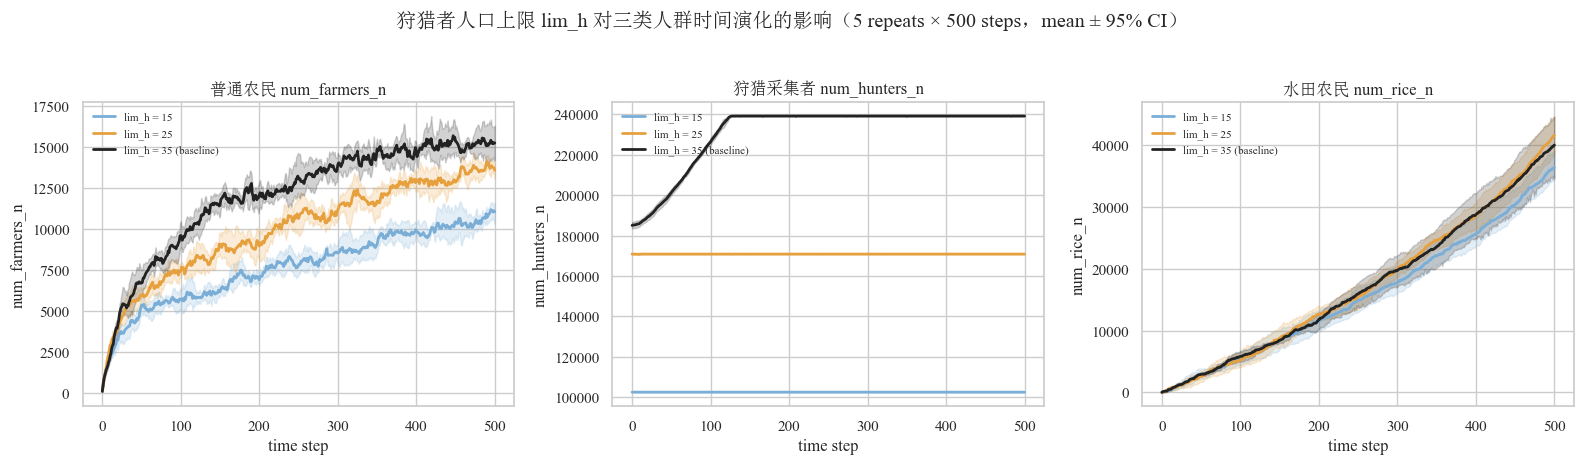

In [7]:
LIMH_ORDER = ["lim_h = 15", "lim_h = 25", "lim_h = 35 (baseline)"]
LIMH_PALETTE = {
    LIMH_ORDER[0]: "#7aaed6",  # 15 — 浅蓝
    LIMH_ORDER[1]: "#e6a03d",  # 25 — 金
    LIMH_ORDER[2]: "#222222",  # 35 baseline — 黑
}

plot_population_comparison(
    limh_df,
    scenarios=LIMH_ORDER,
    palette=LIMH_PALETTE,
    title="狩猎者人口上限 lim_h 对三类人群时间演化的影响（5 repeats × 500 steps，mean ± 95% CI）",
    save_path=PROJECT_ROOT / "reports/secondary_lim_h_sweep.png",
)

In [8]:
limh_summary, limh_ratio = endstate_summary(
    limh_df, LIMH_ORDER, baseline_label=LIMH_ORDER[-1]  # lim_h=35 作为基准
)
print("=== 终态 mean ± std (按 lim_h) ===")
print(limh_summary)
print("\n=== 各 lim_h 相对 baseline (=35) 的倍率 ===")
limh_ratio

=== 终态 mean ± std (按 lim_h) ===
                      num_farmers_n        num_hunters_n      num_rice_n  \
                               mean    std          mean  std       mean   
scenario                                                                   
lim_h = 15                  10547.7  704.5      102525.0  0.0    33494.3   
lim_h = 25                  13611.5  270.8      170874.6  0.6    37858.3   
lim_h = 35 (baseline)       15165.1  670.9      239223.5  3.3    37020.6   

                              len_farmers_n       len_hunters_n         \
                          std          mean   std          mean    std   
scenario                                                                 
lim_h = 15             2900.2         392.4  24.8        7719.1  137.2   
lim_h = 25             3919.3         441.1  13.0        8440.6   81.7   
lim_h = 35 (baseline)  5824.2         457.8  19.0        9222.2   86.5   

                      len_rice_n        
                         

,num_farmers_n,num_hunters_n,num_rice_n,len_farmers_n,len_hunters_n,len_rice_n
scenario,,,,,,
lim_h = 15,0.696,0.429,0.905,0.857,0.837,0.957
lim_h = 25,0.898,0.714,1.023,0.964,0.915,0.981
lim_h = 35 (baseline),1.000,1.000,1.000,1.000,1.000,1.000


### 结论 2：狩猎者人口上限**不是压制华南农业扩散的主导因素**

终态对比（最后 50 步 × 5 repeats 均值）：

| lim_h | num_hunters_n | num_farmers_n | farmer ratio vs 35 |
|---|---:|---:|---:|
| 15 | 102,525 | 10,548 | 0.70 |
| 25 | 170,875 | 13,612 | 0.90 |
| 35 (baseline) | 239,224 | 15,165 | 1.00 |

**判读**：

- `num_hunters_n` 随 `lim_h` 线性下降（由上限定义直接保证，这是sanity check）；
- 但 `num_farmers_n` 并没有因为狩猎者规模缩水而"获得空间" —— 反而**轻微下降**（10.5k → 15k 间波动，ratio 在 0.70–1.00 范围）；
- 这与 `hypothesis_validation.ipynb` H3·续的发现一致：`Hunter.convert_prob.to_farmer` 其实是农民的正向**来源**（~2× 效应），狩猎者越少 → 转成农民的机会越少 → 农民反而略减；
- 无论哪种 `lim_h`，农民终态始终在 10⁴ 量级，与 `Farmer.convert_prob.to_hunter` 导致的 10⁵–10⁶ 量级差异远远不在一个层次；
- ⇒ **狩猎者的人口上限不是压制农业扩散的关键**。农民扩散并非被狩猎者"占满空间"所阻止，而是被退化路径（Farmer→Hunter）所消耗。

---

## 小结

| 检验 | 实验 | 关键对比 | 农民 ratio | 判定 |
|---|---|---|---:|---|
| 地貌均质化 | `2026-03-09/14-43-57`（4 组） | 完全均质 vs baseline | 1.77× | ✅ 次要因素 |
| 狩猎者人口上限 | `2026-03-10/14-01-24`（3 组） | lim_h=15 vs 35 | 0.70× | ✅ 次要因素 |

两组对比中农民终态都保持在 10⁴ 量级，与主导机制（`Farmer.convert_prob.to_hunter` 单路径即可产生 ~27× 效应）相比**至少差一个数量级**。

**完整归因链（结合 `hypothesis_validation.ipynb`）**：

1. 华南环境确实压制普通农民扩散（基准下只长到 15k，远低于未受压制时的 100k+）——这是核心现象。
2. 压制的主导机制是 **convert 机制的源/汇不对称**：`Farmer.convert_prob.to_hunter` 作为农民的主要汇（农民退化回狩猎者），与 `RiceFarmer.convert_prob.to_farmer = 1.0` 作为主要源（水田农民补充农民）之间达成的动态平衡。
3. 地貌起伏、狩猎者人口上限虽然都有次级影响（1.77× 与 0.70×），但都**不改变基本量级**，因此不是华南环境特殊性的主因。

这也解释了为什么把华南换成别的地区地貌、或者把狩猎者上限随便改一改都不会戏剧性地改变农民扩散 —— 压制的"真凶"藏在转化规则里。